# The First Part of the Assignment of IDS 2019-2020
Document your results as well as the way you obtained them in this jupyter notebook. A seperate report (pdf, word etc.) is _not_ required. However, it is necessary that you provide the python code leading to your results as well as textual answers to the assignment questions in this notebook. *DO NOT CLEAR THE OUTPUT of the notebook your are submitting!* In the cases that the result of an algorithm is pdf, jpg, etc, you should attach the result to this notebook file and refer to that in the text.  

Next to the jupyter notebook, submit one zip-file containing all data sets that you are asked to submit. Make sure they are easily identifiable, i.e. use names as requested in the corresponding question.

Do not change the general structure of this notebook, but you can add further markdown or code cells to explain your solutions if necessary. In the end, submit this file and your created data sets in moodle.

Only <font color="red">one </font> group member should upload your group's solution. *Make sure to include group members' names and matriculation numbers*. If your name and student id are not included in the report, you will not receive any points!


Hint 1: While answering the questions, you will get a better and better impression of the given data. However, feel free to compute additional results and vizualizations to motivate the decisions you need to make, for example with respect to modification, simplification or sampling of the data. <font color="red"><b>Ensure that all claims you make are supported by the presented facts!</b></font>

Hint 2: <font color="red"><b>Some of the tasks might need some time to run. Take this into account in your planning.</b></font>

Hint 3: RWTHonline allows for multiple submissions (each submission overwrites the previous ones). <font color="red"><b>Partial submissions are possible and encouraged. </b></font> This helps in case of technical problems of RWTHonline, which do seldomly happen.

<font color="red"><b>Student Names and IDs:
    1. Niklas Gruhn (389343)
    2. Yat Wai Wong (391265)
    3. Anisa Kusumadewi (402433)

## Preprocessing of the Dataset (5 points)
 You should carry out some preprocessing steps before starting the analysis:
 - Select 90% of 'population_density' dataset by random sampling.
     - Use one of the group member's student number as a seed.
 - Add another column to the dataset:
     - Name it 'population_density_categorical'.
     - The values in this column depend on values in 'population_density' column and will be defined as follows:
        - 5824=<population density              corresponding value in 'population_density_categorical' column: 'very high'
        - 4368=<population density<5824         corresponding value in 'population_density_categorical' column: 'high'
        - 2912=<population density<4368         corresponding value in 'population_density_categorical' column: 'medium'
        - 1456=<population density<2912         corresponding value in 'population_density_categorical' column: 'low' 
        - population density<1456               corresponding value in 'population_density_categorical' column: 'very low'
 - After completing this preprocessing step, export your final dataset as 'population_density_categorical.csv' dataset and use that for next steps of the assignment.
 - If it is not directly mentioned, you should always use your extracted (above-created) dataset (without any cleaning).
 - <font color='red'>Important!</font> Make sure that you submit your extracted dataset with your result in moodle.

In [239]:
import pandas as pd

# load data set
dataset = pd.read_csv("./population_density.csv");

# select random sample
dataset = dataset.sample(frac=0.9, random_state=389343)

# add column "population_density_categorical"
def population_density_category(density: int):
    if density >= 5824:  
        return "very high"
    elif density >= 4368:
        return "high"
    elif density >= 2912:
        return "medium"
    elif density >= 1456:
        return "low"
    else:
        return "very low"

dataset["population_density_categorical"] = dataset["population_density"].map(population_density_category)

# export dataset
dataset.to_csv("./population_density_categorical.csv")

# display dataset
dataset

,holiday,temperature,rain_1h,snow_1h,clouds_percentage,weather_type,weather_type_details,date_time,population_density,population_density_categorical
18490,None,290.31,0.00,0.0,1,Clear,sky is clear,9/22/2015 23:00,987,very low
40262,None,247.76,0.00,0.0,1,Clear,sky is clear,1/1/2018 7:00,677,very low
34430,None,289.55,0.00,0.0,90,Thunderstorm,proximity thunderstorm,6/11/2017 12:00,4039,medium
45577,None,295.82,0.00,0.0,1,Haze,haze,7/5/2018 0:00,971,very low
4677,None,276.92,0.00,0.0,90,Rain,heavy intensity rain,3/31/2013 7:00,908,very low
...,...,...,...,...,...,...,...,...,...,...
43723,None,290.92,0.00,0.0,90,Clouds,overcast clouds,5/1/2018 11:00,4473,high
39011,None,274.58,0.00,0.0,40,Clouds,scattered clouds,11/17/2017 1:00,469,very low
6373,None,289.37,0.00,0.0,1,Clear,sky is clear,5/24/2013 20:00,2833,low
8113,None,297.55,0.00,0.0,64,Clouds,broken clouds,8/1/2013 14:00,5845,very high


## Question 1 - Insights into the Data (20 points):

### Dealing with Outliers (10 points)
   (a) Use a boxplot to find and remove the outliers from "temperature". Note that based on the boxplot the values greater than upper-whisker and less than lower-whisker are considered as the outliers. Now you should  have two datasets (cleaned and original).

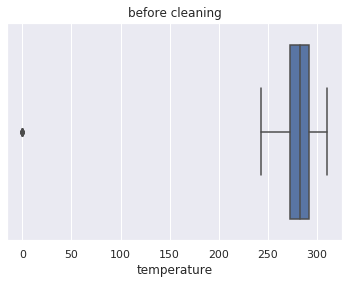

In [240]:
import seaborn as sns

dataset_original = pd.read_csv("./population_density_categorical.csv");

axes = sns.boxplot(dataset_original["temperature"])
axes.set_title("before cleaning")
plt.show()

While apparent form the boxplot above, all outliers are far off removed from the lower whisker, around the zero degree mark. We could therefore filter the dataset "by eye". For example by simply removing all rows with temperature values below 50 degrees. However, we might have removed larger outliers when we generated the sample from the hole dataset. So to make sure the result is perfectly reproducable we explicitly remove all data points outside the upper- and lower-whisker:

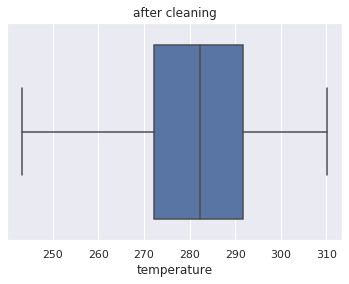

In [241]:
temperature_column = dataset_original["temperature"]

upper_quartile = temperature_column.quantile(0.75)
lower_quartile = temperature_column.quantile(0.25)

IQR = upper_quartile - lower_quartile

upper_whisker_estimate = temperature_column <= upper_quartile + 1.5 * IQR
lower_whisker_estimate = temperature_column >= lower_quartile - 1.5 * IQR

# find actual data points of whiskers
upper_whisker = temperature_column[upper_whisker_estimate].max()
lower_whisker = temperature_column[lower_whisker_estimate].min()

dataset_cleaned = dataset_original.copy()
dataset_cleaned = dataset_cleaned.loc[(temperature_column >= lower_whisker) & (temperature_column <= upper_whisker),:]

axes = sns.boxplot(dataset_cleaned["temperature"])
axes.set_title("after cleaning")
plt.show()

   (b) Compare basic statistical features of "temperature" (median, mean, and mode) in the cleaned and original datasets.    Interpret the differences for these statistical values between the cleaned and original datasets. 

In [242]:
medians = [
    dataset_original["temperature"].median(), 
    dataset_cleaned["temperature"].median()
]

means = [
    dataset_original["temperature"].mean(),
    dataset_cleaned["temperature"].mean()
]

modes = [
    dataset_original["temperature"].mode()[0],
    dataset_cleaned["temperature"].mode()[0] 
]

# put in a dataframe for a simple way to print a table
pd.DataFrame({
    "dataset": ["original", "cleaned"],
    "median": medians,
    "mean": means,
    "mode": modes
}).set_index("dataset")

,median,mean,mode
dataset,,,
original,282.35,281.18407,274.15
cleaned,282.36,281.23593,274.15


#### Interpretation

We would expect the `median` to be largely unaffected when we remove outliers. In fact, that's exactly what we observe. 

The `mean` on the other hand is very sensitve to the presence or absence of outliers so we would expect to see significant change. As it turns out (see below), the number of removed outliers is very small compared to the size of the overall dataset so the impact of outliers is watered-down by the sheer number of non-outlier instances.

`mode` measures the most frequently appearing value. So it should only be affected when we remove instances from this group or add instances such that a different group becomes most frequent. This too is not to be expected when we remove so few outliers. Thus, the `mode` is still the same as well.

   (c) Compare the number of data rows before and after removing the outliers. How many data rows are removed by removing    outliers?

In [243]:
print("==== Instance Count ====\n")
print(len(dataset_original), "in original dataset")
print(len(dataset_cleaned), "in cleaned dataset ")
print("\ndifference =", len(dataset_original) - len(dataset_cleaned))

==== Instance Count ====

43384 in original dataset
43376 in cleaned dataset 

difference = 8


### Basic Visualization (10 points)
   (d) Visualize mean and median of "population_density" for non-'None' "holiday" values in the original dataset. Specify    the "holiday" values for which the mean of "population_density" is maximal and for which it is minimal.

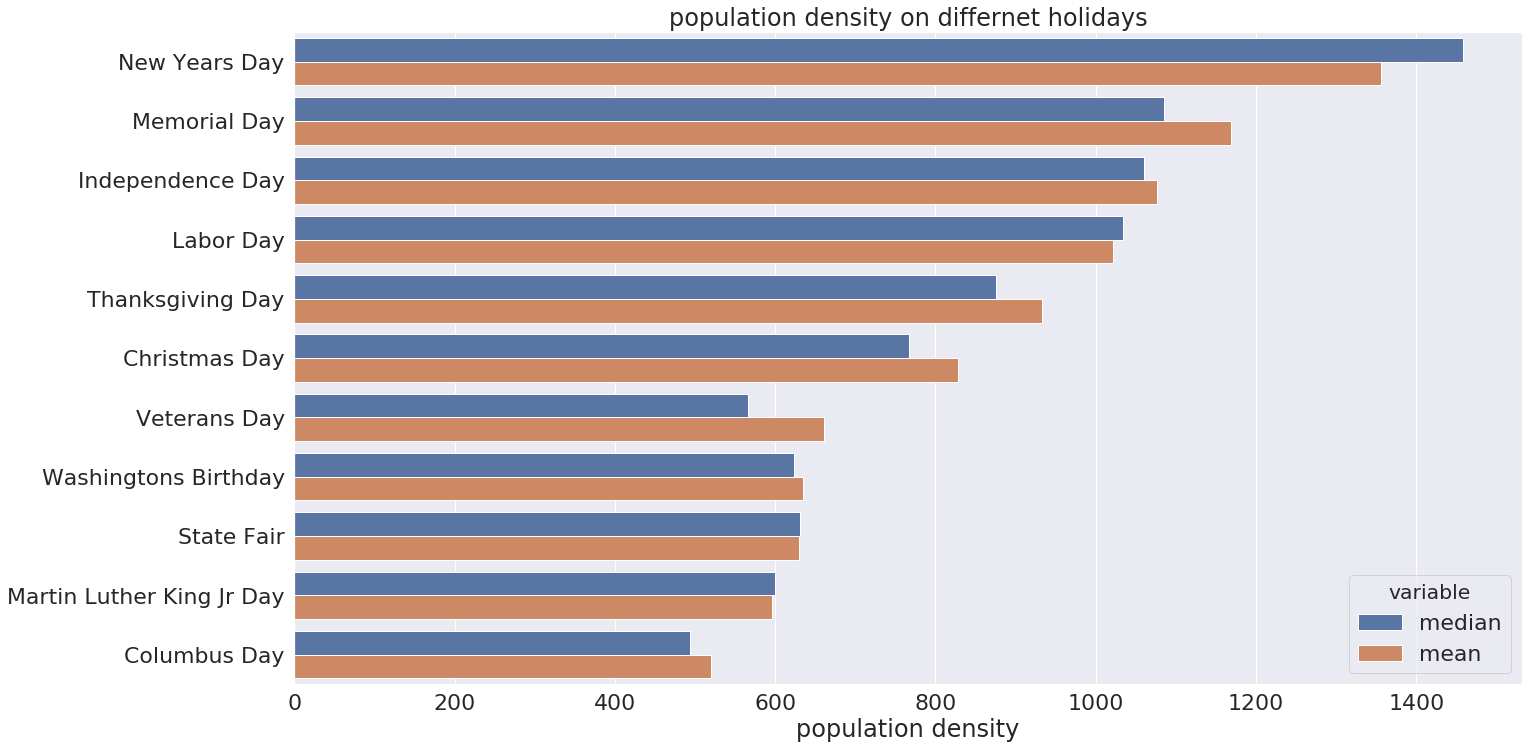

In [244]:
from numpy import median 
import matplotlib.pyplot as plt

# filter out non-holiday data instances
dataset_has_holiday = dataset_original.loc[dataset_original["holiday"] != "None", ["holiday", "population_density"]]

# prepare dataset such that we can plot mean/median in single barplot
dataset_plotable = dataset_has_holiday.groupby("holiday").mean()
dataset_plotable = dataset_plotable.rename(columns={ "population_density": "mean" })
dataset_plotable["median"] = dataset_has_holiday.groupby("holiday").median()
dataset_plotable = dataset_plotable.reset_index()
dataset_plotable = pd.melt(dataset_plotable, id_vars="holiday")
dataset_plotable = dataset_plotable.sort_values(by="value", ascending=False)

# using horizontal barplot to make the holiday ticks more readable 
plt.figure(figsize=(22,12))
sns.set(font_scale = 2)

axes = sns.barplot(data=df, y="holiday", x="value", hue="variable")
axes.set_ylabel("")
axes.set_xlabel("population density")
axes.set_title("population density on differnet holidays")
plt.show()

sns.set(font_scale = 1)

As apparent from the barplot above, the maximal mean `population_density` is on *New Years Day* while the minimum is on *Columbus Day*.

   (e) Plot the distribution of "temperature" in the original and cleaned datasets.

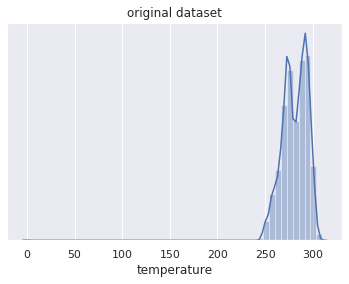

In [245]:
ax_original = sns.distplot(dataset_original["temperature"])
ax_original.set_title("original dataset")
ax_original.set_yticks([])
plt.show()

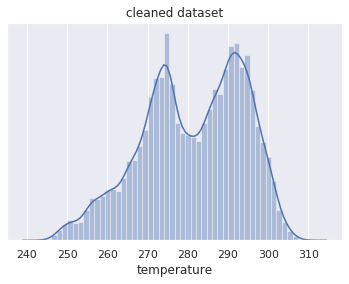

In [246]:
ax_cleaned = sns.distplot(dataset_cleaned["temperature"])
ax_cleaned.set_title("cleaned dataset")
ax_cleaned.set_yticks([])
plt.show()

   (f) Explore the distribution of "population_density" and "temperature" together in the cleaned dataset. Specify the ranges of "temperature" and "population_density" for which the frequency of the data is the highest.

<Figure size 2880x864 with 0 Axes>

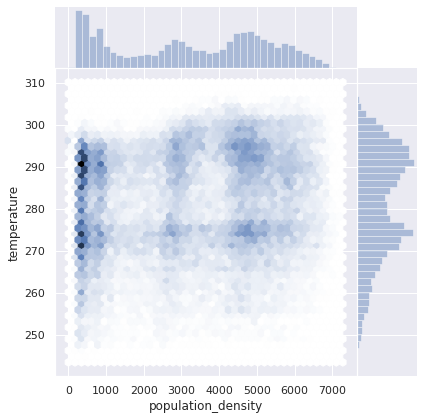

In [247]:
plt.figure(figsize=(40,12))
sns.jointplot(x="population_density", y="temperature", data=dataset_cleaned, marginal_kws=dict(bins=40),annot_kws=dict(stat="r"), kind="hex", space = 0);  #kind= scatter, hex, reg,kde 
plt.show()

As you can see in the joint plot, data in the range 'population density =  around 400' and 'temperature between 290 and 292' appears most frequently.

## Question 2 - Decision Trees (15 points):

   (a) Add a categorical temperature column to the cleaned dataset based on the following rules and name it                "temperature_categorical":
        - temperature >= upper_quartile (third quartile) corresponding value in 'temperature_categorical' column: 'high'
        - temperature <= lower_quartile (first quartile) corresponding value in 'temperature_categorical' column: 'low'
        - lower_quartile < temperature < upper_quartile corresponding value in 'temperature_categorical' column: 'medium'

In [248]:
dataset_q2 = dataset_cleaned.copy()

temperature_column = dataset_q2.loc[:,"temperature"]

# add column "temperature_categorical"
lower_quartile = temperature_column.quantile(0.25)
upper_quartile = temperature_column.quantile(0.75)

def temperature_categorical(temperature):
    if temperature >= upper_quartile:  
        return "high"
    elif temperature <= lower_quartile:
        return "low"
    else:
        return "medium"

dataset_q2["temperature_categorical"] = temperature_column.map(temperature_categorical)
dataset_q2

,Unnamed: 0,holiday,temperature,rain_1h,snow_1h,clouds_percentage,weather_type,weather_type_details,date_time,population_density,population_density_categorical,temperature_categorical
0,18490,None,290.31,0.00,0.0,1,Clear,sky is clear,9/22/2015 23:00,987,very low,medium
1,40262,None,247.76,0.00,0.0,1,Clear,sky is clear,1/1/2018 7:00,677,very low,low
2,34430,None,289.55,0.00,0.0,90,Thunderstorm,proximity thunderstorm,6/11/2017 12:00,4039,medium,medium
3,45577,None,295.82,0.00,0.0,1,Haze,haze,7/5/2018 0:00,971,very low,high
4,4677,None,276.92,0.00,0.0,90,Rain,heavy intensity rain,3/31/2013 7:00,908,very low,medium
...,...,...,...,...,...,...,...,...,...,...,...,...
43379,43723,None,290.92,0.00,0.0,90,Clouds,overcast clouds,5/1/2018 11:00,4473,high,medium
43380,39011,None,274.58,0.00,0.0,40,Clouds,scattered clouds,11/17/2017 1:00,469,very low,medium
43381,6373,None,289.37,0.00,0.0,1,Clear,sky is clear,5/24/2013 20:00,2833,low,medium
43382,8113,None,297.55,0.00,0.0,64,Clouds,broken clouds,8/1/2013 14:00,5845,very high,high


   (b) In the new dataset (created in Section 'a'), consider "holiday", "temperature_categorical", and "weather_type" as    the descriptive features and "population_density_categorical" as the target feature. Set the minimum number of samples  for splitting to 5000 and make a decision tree based on entropy.

You either have not installed the 'dot' to visualize the decision tree or the reulted .pdf file is open!


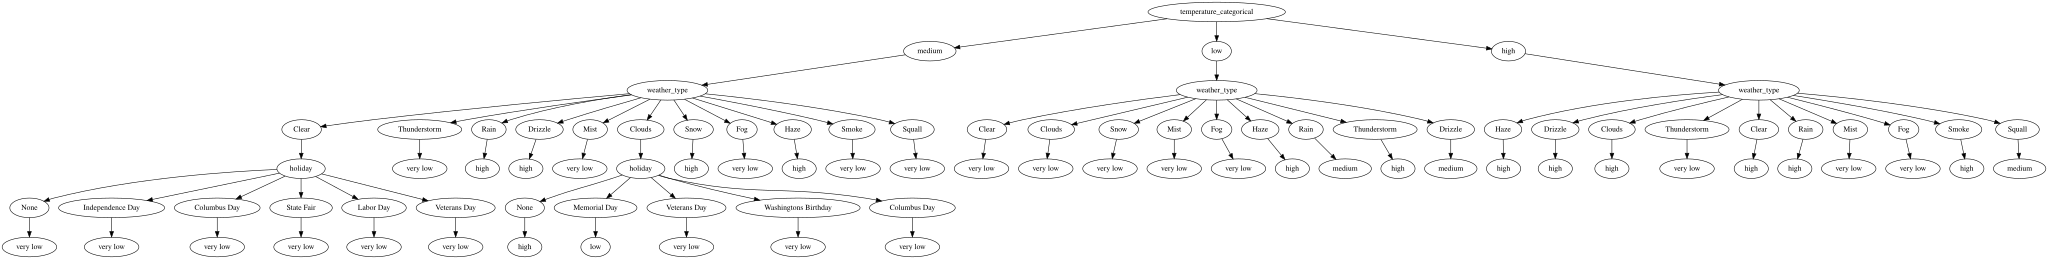

Entropy:  2.23009132569555


In [249]:
from p_decision_tree.DecisionTree import DecisionTree

target_feature = "population_density_categorical"
descriptive_features = [
    "holiday", 
    "temperature_categorical", 
    "weather_type"
]

decision_tree = DecisionTree(
    list(dataset_q2[descriptive_features].values), 
    descriptive_features,
    list(dataset_q2[target_feature].values), 
    criterion="entropy"
)

decision_tree.id3(0, 5000)

display(decision_tree.print_visualTree(render=True))

print("Entropy: ", format(decision_tree.entropy))

   (c) What is the best attribute (based on entropy) for splitting the tree in the second round of ID3?  

#### Explanation

## Question 3 - Regression (10 points):

For this question (Q3), restrict your extracted data set to the columns *holiday, temperature, rain_1h, snow_1h, clouds_percentage, date_time* and *population_density*. Drop the information on the date for *date_time* and restrict the data to time values (hour) only.

We define *population_density* to be our target feature, while all other features are considered descriptive.

In [250]:
# Your code:
dataset_question3 = pd.read_csv("./population_density_categorical.csv");

dataset_question3 = dataset_question3[["holiday", "temperature", "rain_1h", "snow_1h", "clouds_percentage", "date_time", "population_density"]]
datetime_hours_only = pd.to_datetime(dataset_question3["date_time"]).dt.hour
dataset_question3["date_time"] = datetime_hours_only

descriptive_feature = dataset_question3[["holiday", "temperature", "rain_1h", "snow_1h", "clouds_percentage", "date_time"]]
target_feature = dataset_question3["population_density"]

print(descriptive_feature[:3])


  holiday  temperature  rain_1h  snow_1h  clouds_percentage  date_time
0    None       290.31      0.0      0.0                  1         23
1    None       247.76      0.0      0.0                  1          7
2    None       289.55      0.0      0.0                 90         12


   (a) Which features are suitable as an input for linear regression and which need to be modified first? Why?

Explanation:
holidays need to be modified first because it is a catergorical features, and we can change holiday to 0/1 value for all possible values (i.e. one hot encoding)

   (b) Implement and briefly motivate an adequate modification. Print the resulting data set limited to the first two data rows.

Explanation:


In [251]:
# Your code:
#implementation of one hot encoding on holiday
dataset_question3_one_hot = pd.get_dummies(dataset_question3)
print(dataset_question3_one_hot[:2])

   temperature  rain_1h  snow_1h  clouds_percentage  date_time  \
0       290.31      0.0      0.0                  1         23   
1       247.76      0.0      0.0                  1          7   

   population_density  holiday_Christmas Day  holiday_Columbus Day  \
0                 987                      0                     0   
1                 677                      0                     0   

   holiday_Independence Day  holiday_Labor Day  \
0                         0                  0   
1                         0                  0   

   holiday_Martin Luther King Jr Day  holiday_Memorial Day  \
0                                  0                     0   
1                                  0                     0   

   holiday_New Years Day  holiday_None  holiday_State Fair  \
0                      0             1                   0   
1                      0             1                   0   

   holiday_Thanksgiving Day  holiday_Veterans Day  \
0           

(c) To get a first idea about our data, plot the behaviour of the target feature (population_density) over time (date_time).

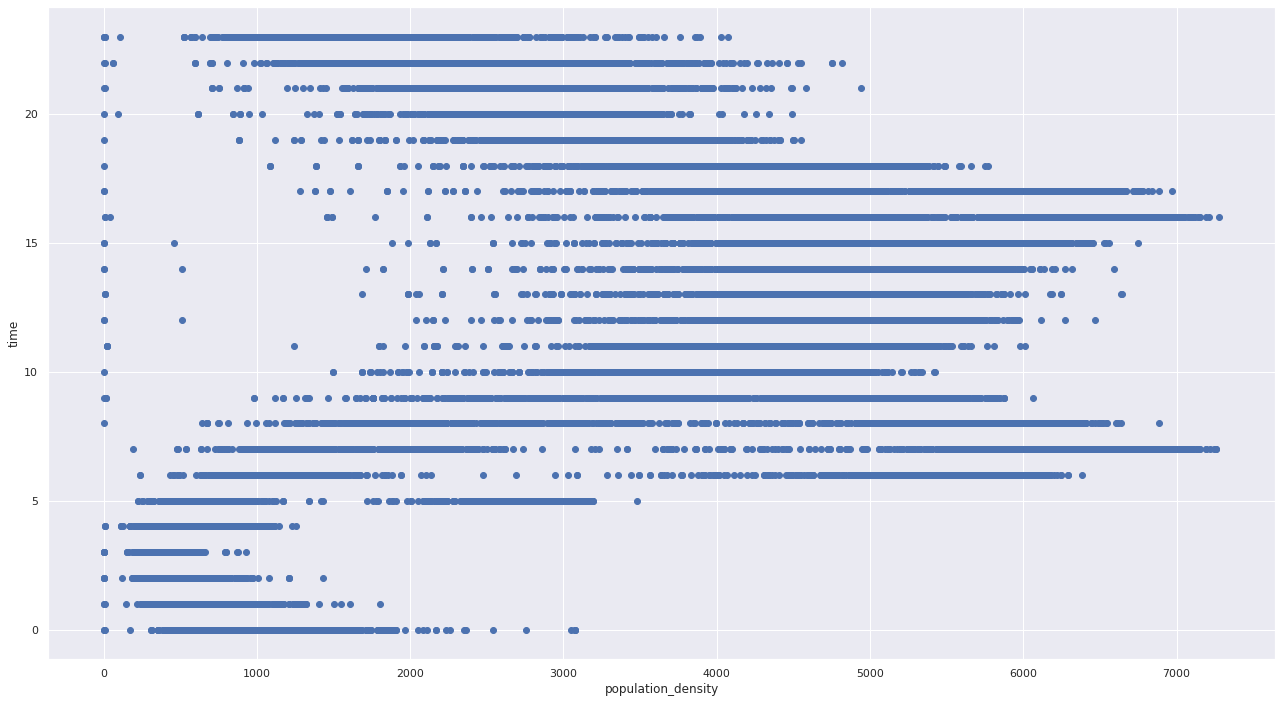

In [252]:
# Your code:

plt.figure(figsize=(22,12))
time_plot = plt.scatter(dataset_question3_one_hot["population_density"], dataset_question3_one_hot["date_time"])
plt.xlabel("population_density")
plt.ylabel("time")
plt.show()


   (d) Create two distinct subsets of the data. Use sampling methods as described in the lecture. You should end up with two DIFFERENT sample data sets *RegA, RegB*. Include these data sets in the submitted data set zip file. 
   
   Which sampling methods did you choose and why? Which one do you expect to result in a better classifier?

In [253]:
# Your code:
from sklearn.model_selection import train_test_split

#We use top sampling for RegA. RegA is the top 60% of the dataset
RegA = dataset_question3_one_hot[: int(len(dataset_question3) *0.6)]
RegA.to_csv("./RegA.csv")
#We use random sampling for RegB
features = RegA.columns.tolist()
features.remove('population_density')

RegB = dataset_question3_one_hot.sample(frac=0.6, random_state=391265, replace=False)
RegB.to_csv("./RegB.csv")


Explanation:
We use top sampling and random sampling because we don't see any imbalance of values in the columns 


   (e) Train a linear regression classifier based on each of the two sample data sets *RegA, RegB* created before.

In [254]:
# Your code:
from sklearn.linear_model import LinearRegression

#define the classifier
classifierA = LinearRegression()
classifierB = LinearRegression()

#train the classifier
features = RegA.columns.tolist()
features.remove('population_density')

descriptive_featureA = RegA[features]
target_featureA = RegA["population_density"]

descriptive_featureB = RegB[features]
target_featureB = RegB["population_density"]

modelA = classifierA.fit(descriptive_featureA, target_featureA)
modelB = classifierB.fit(descriptive_featureB, target_featureB)

y_pred_A = classifierA.predict(dataset_question3_one_hot[features])
y_pred_B = classifierB.predict(dataset_question3_one_hot[features])

(f) Visualize both computed regression functions in one plot each, combined with the original data set. For example, you can show a plot similar to 3(c) and insert the regression functions result.

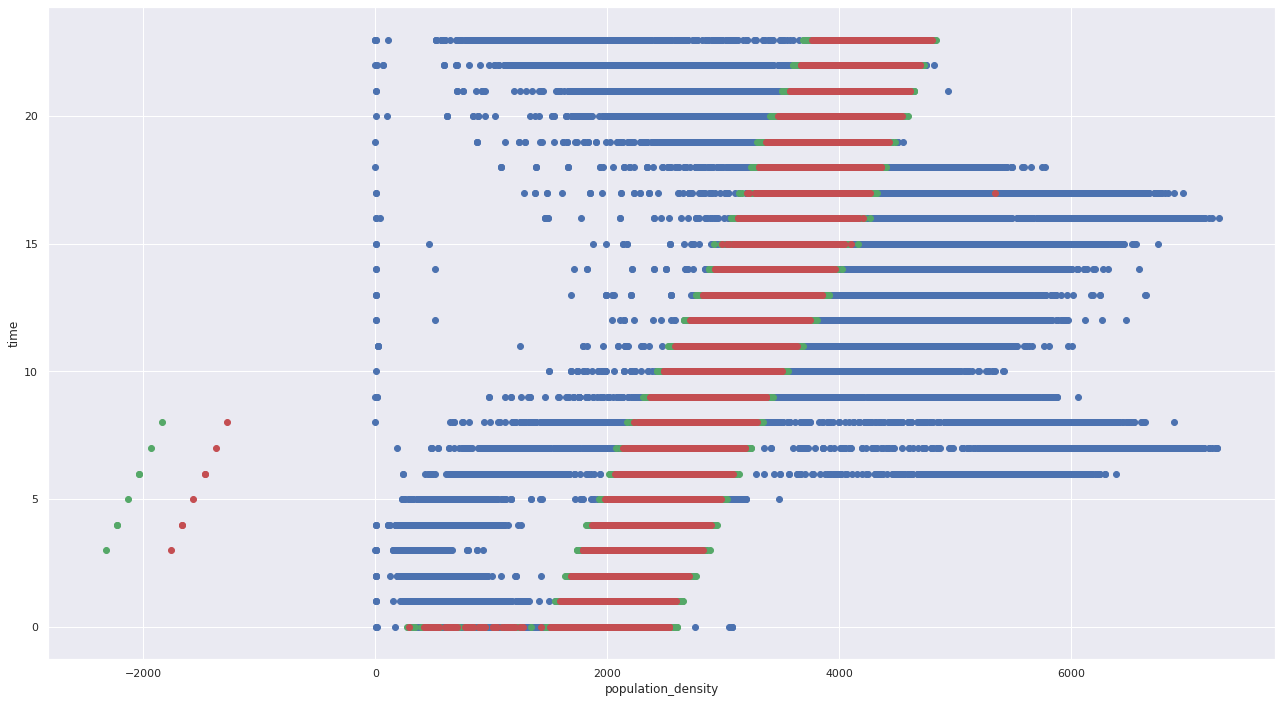

In [255]:
# Your code:

plt.figure(figsize=(22,12))
time_plot = plt.scatter(dataset_question3_one_hot["population_density"], dataset_question3_one_hot["date_time"])
plt.scatter( y_pred_A, dataset_question3_one_hot["date_time"],color = "g") 
plt.scatter( y_pred_B, dataset_question3_one_hot["date_time"],color = "r") 

plt.xlabel("population_density")
plt.ylabel("time")
plt.show()



   (g) For each of the two resulting models compute and print the mean squared error, mean absolute error and median squared error with respect to the original, non-sampled data set. Also, present plots showing the errors and squared errors.

Mean squared error:
MSE of RegA:  3397799.55890012
MSE of RegB:  3397315.407862946
Mean absolute error of RegA:  1628.5498104325388
Mean absolute error of RegB:  1629.027124224931
Median squared error of RegA:  10204.258386214662
Median squared error of RegB:  12168.531643218039


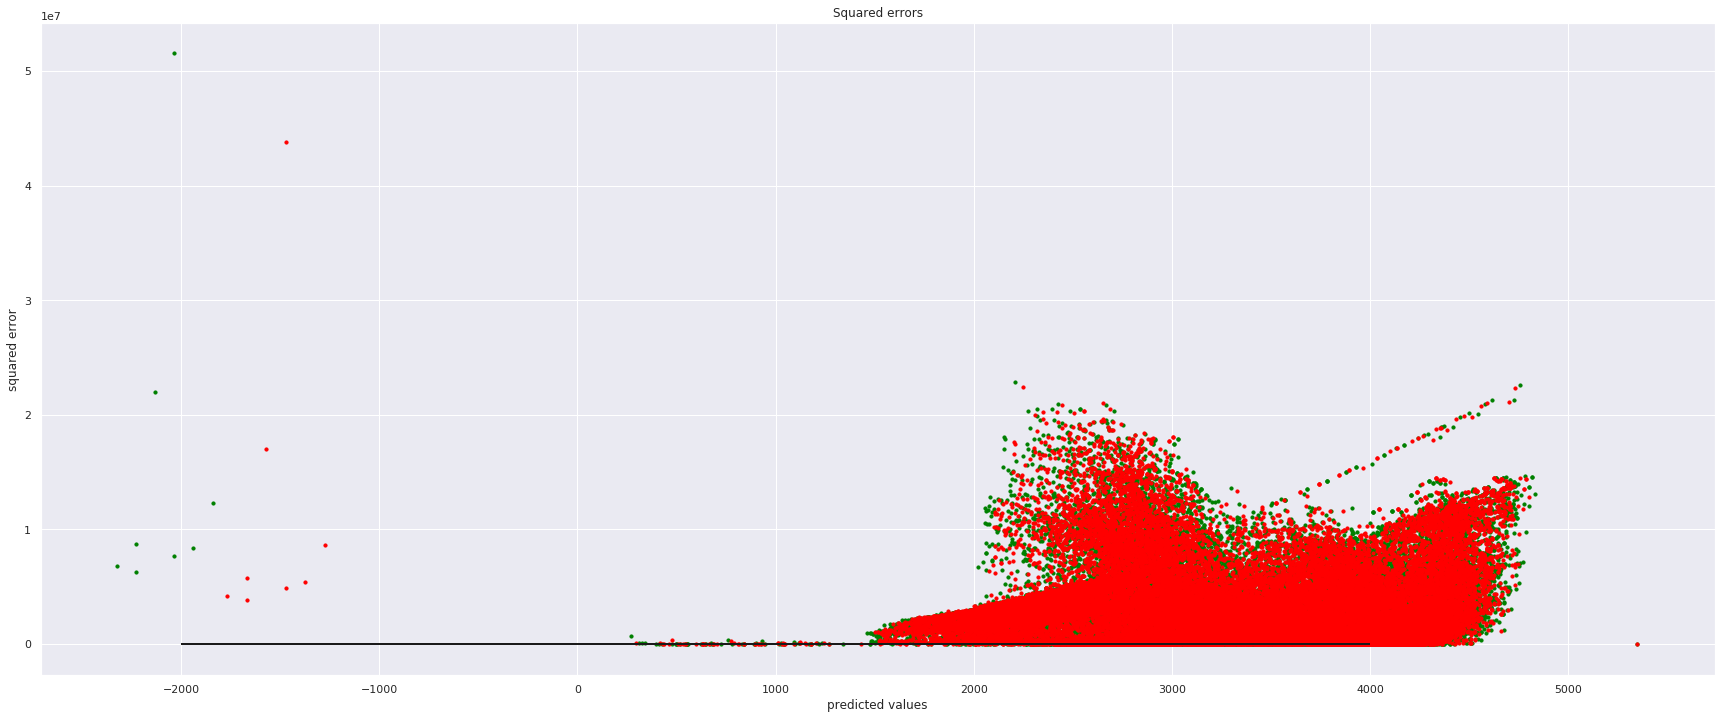

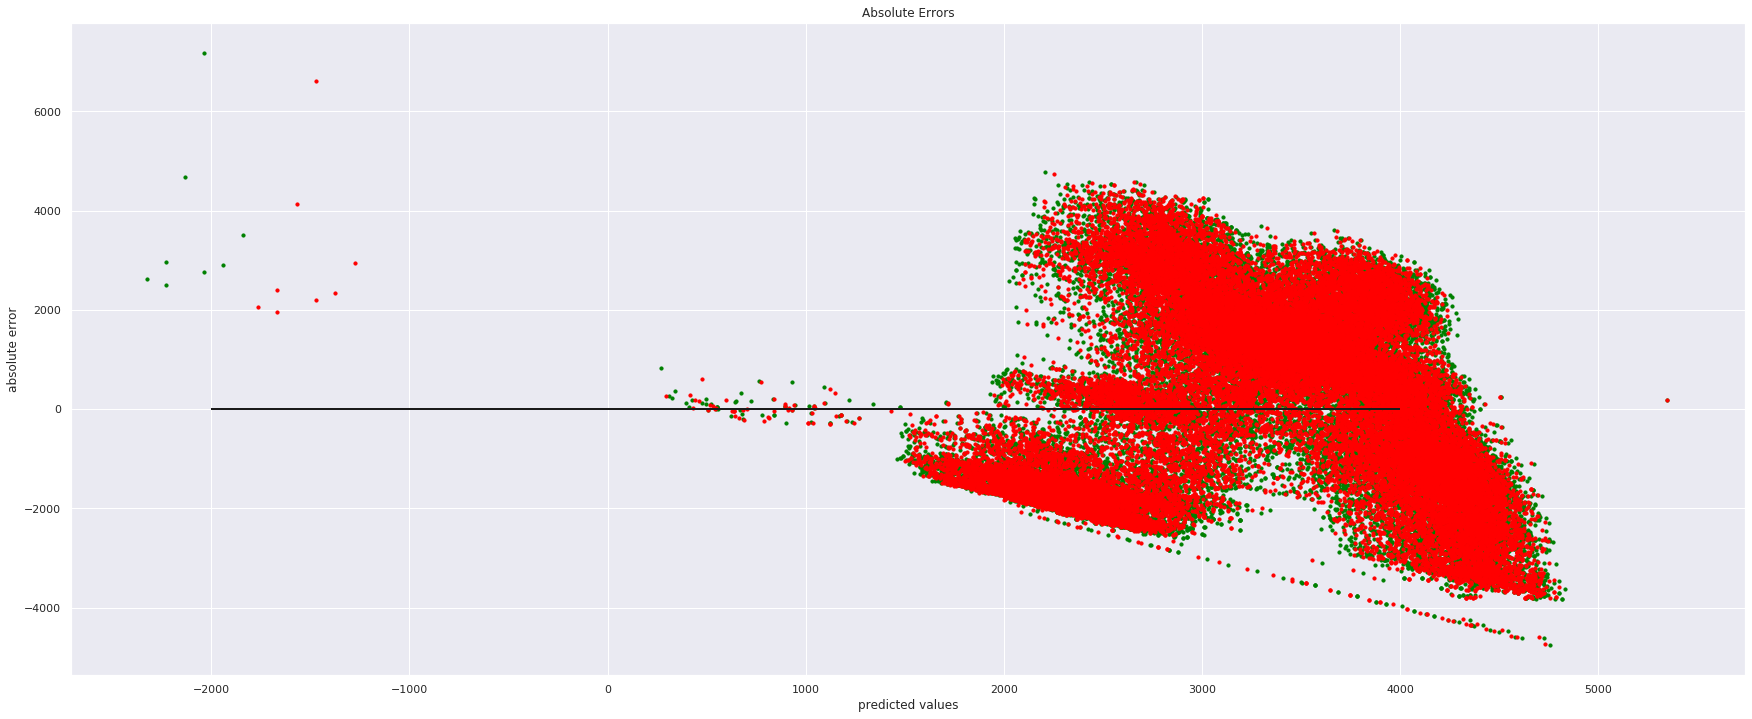

In [256]:
# Your code:
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("Mean squared error:")
print("MSE of RegA: ", mean_squared_error(dataset_question3_one_hot["population_density"], y_pred_A))
print("MSE of RegB: ", mean_squared_error(dataset_question3_one_hot["population_density"], y_pred_B))

print("Mean absolute error of RegA: ", mean_absolute_error(dataset_question3_one_hot["population_density"], y_pred_A))
print("Mean absolute error of RegB: ", mean_absolute_error(dataset_question3_one_hot["population_density"], y_pred_B))

import numpy as np 
print("Median squared error of RegA: ", (dataset_question3_one_hot.loc[:,"population_density"].median() - np.median(y_pred_A)) **2 ) 
print("Median squared error of RegB: ", (dataset_question3_one_hot.loc[:,"population_density"].median() - np.median(y_pred_B)) **2 ) 

#plot for squared error 
plt.figure(figsize=(30,12))
plt.scatter(y_pred_A, (dataset_question3_one_hot["population_density"] - y_pred_A) ** 2, color = "green", s = 10,) 
plt.scatter(y_pred_B, (dataset_question3_one_hot["population_density"] - y_pred_B) ** 2, color = "red", s = 10,) 
plt.title("Squared errors")
## plotting line for zero error 
plt.hlines(y = 0, xmin = -2000, xmax = 4000, linewidth = 2) 
plt.xlabel('predicted values')
plt.ylabel('squared error')
plt.show()

#plot for absolute error
plt.figure(figsize=(30,12))

plt.scatter(y_pred_A, (dataset_question3_one_hot["population_density"] - y_pred_A), color = "green", s = 10,) 
plt.scatter(y_pred_B, (dataset_question3_one_hot["population_density"] - y_pred_B), color = "red", s = 10,) 
plt.title("Absolute Errors")
plt.hlines(y = 0, xmin = -2000, xmax = 4000, linewidth = 2) 
plt.xlabel('predicted values')
plt.ylabel('absolute error')
plt.show()


   (h) Interpret and evaluate the two models and compare them. Why are they similar/different? Which model do you recommend and why? How do you think the applied methods could be improved to get better results?

Explanation:
They are similar because even the top 60% of rows are evenly distribute, so top sampling is similar to random sampling. Stratified random sampling may get a better result.

## Question 4 - Support Vector Machines (10 points):

For this question (Q4), restrict your extracted data set to the columns *holiday, temperature, rain_1h, snow_1h, clouds_percentage, date_time* and *population_density_categorical*. For *date_time*, drop the information on the date and restrict the data to time values only.
We define *population_density_categorical* to be our target feature, while all other features are considered descriptive.


In [257]:
features = [
    "holiday",
    "temperature",
    "rain_1h",
    "snow_1h",
    "clouds_percentage",
    # "date_time",
    "population_density_categorical"
]

dataset_q4 = dataset.loc[:, features]
dataset_q4["hour"] = pd.to_datetime(dataset["date_time"]).dt.hour

dataset_q4

,holiday,temperature,rain_1h,snow_1h,clouds_percentage,population_density_categorical,hour
18490,None,290.31,0.00,0.0,1,very low,23
40262,None,247.76,0.00,0.0,1,very low,7
34430,None,289.55,0.00,0.0,90,medium,12
45577,None,295.82,0.00,0.0,1,very low,0
4677,None,276.92,0.00,0.0,90,very low,7
...,...,...,...,...,...,...,...
43723,None,290.92,0.00,0.0,90,high,11
39011,None,274.58,0.00,0.0,40,very low,1
6373,None,289.37,0.00,0.0,1,low,20
8113,None,297.55,0.00,0.0,64,very high,14


   (a) Which features are suitable as an input for SVM and which need to be modified first? Modify the data as needed and provide a brief explanation.

In [258]:
def population_density_category_to_number(category):
    return { "very high": 4, "high": 3, "medium": 2, "low": 1, "very low": 0 }[category]

def population_density_number_to_category(number):
    return [ "very low", "low", "medium", "high", "very high" ][number]

In [259]:
dataset_q4_mod = dataset_q4.copy()
dataset_q4_mod["population_density_categorical"] = dataset_q4["population_density_categorical"].map(population_density_category_to_number)
dataset_q4_mod = pd.get_dummies(dataset_q4_mod, columns=["holiday"])
dataset_q4_mod

,temperature,rain_1h,snow_1h,clouds_percentage,population_density_categorical,hour,holiday_Christmas Day,holiday_Columbus Day,holiday_Independence Day,holiday_Labor Day,holiday_Martin Luther King Jr Day,holiday_Memorial Day,holiday_New Years Day,holiday_None,holiday_State Fair,holiday_Thanksgiving Day,holiday_Veterans Day,holiday_Washingtons Birthday
18490,290.31,0.00,0.0,1,0,23,0,0,0,0,0,0,0,1,0,0,0,0
40262,247.76,0.00,0.0,1,0,7,0,0,0,0,0,0,0,1,0,0,0,0
34430,289.55,0.00,0.0,90,2,12,0,0,0,0,0,0,0,1,0,0,0,0
45577,295.82,0.00,0.0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4677,276.92,0.00,0.0,90,0,7,0,0,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43723,290.92,0.00,0.0,90,3,11,0,0,0,0,0,0,0,1,0,0,0,0
39011,274.58,0.00,0.0,40,0,1,0,0,0,0,0,0,0,1,0,0,0,0
6373,289.37,0.00,0.0,1,1,20,0,0,0,0,0,0,0,1,0,0,0,0
8113,297.55,0.00,0.0,64,4,14,0,0,0,0,0,0,0,1,0,0,0,0


Explanation: SVMs can't handle categorical features out of the box. The only categorical features in this case are `holiday` and `population_density_categorical`. We can simply map `population_density_categorical` to numeric values. `holiday` however is not inherently ordinal, thus we must leverage one-hot-encoding here. 

   (b) Divide the data set into a training set *svmTrain* and a test set *svmTest* and briefly motivate your division      strategy. Include these data sets in the data set zip file you submit. 
   
   Hint: Training the SVMs will take longer for a large training set!

In [260]:
from sklearn.model_selection import train_test_split

svm_train, svm_test = train_test_split(dataset_q4_mod, test_size=0.5, random_state=2019)

svm_train = svm_train.head(1000)
svm_test = svm_test.head(1000)

svm_train.to_csv("svmTrain.csv")
svm_test.to_csv("svmTest.csv")

#### Explanation

Since training SVMs is so expensive (1000 instances for 3 models already took several minutes) we choose only a small training dataset.

   (c) Use the training set to train 3 different SVMs with different combinations of the parameters. Use at least two distinct values for the parameters *kernel* and *C*.

In [261]:
from sklearn.svm import SVC

def target_feature(df):
    return df.loc[:,"population_density_categorical"]
    
def descriptive_features(df):
    columns = list(df.columns)
    columns.remove("population_density_categorical")
    return df.loc[:, columns]

svm_train_X = descriptive_features(svm_train)
svm_train_y = target_feature(svm_train)

# train the three different SVM models
svm_models = [
    SVC(C=1, kernel="rbf"), # default
    SVC(C=0.01, kernel="rbf"),
    SVC(C=1, kernel="poly")
]

for model in svm_models:
    model.fit(svm_train_X, svm_train_y)

/opt/conda/lib/python3.7/site-packages/sklearn/svm/base.py:193: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)
/opt/conda/lib/python3.7/site-packages/sklearn/svm/base.py:193: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)
/opt/conda/lib/python3.7/site-packages/sklearn/svm/base.py:193: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


   (d) Compute and print the mean accurracy and classification report of the trained SVMs with respect to the test set (as shown in instruction).

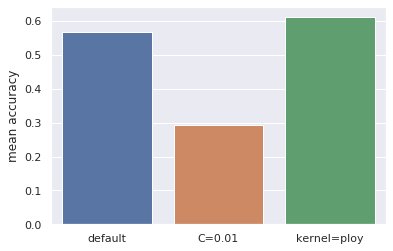



==================== Classification Report ==================== 

              precision    recall  f1-score   support

    very low       0.80      0.84      0.82       294
         low       0.42      0.37      0.39       152
      medium       0.35      0.41      0.38       181
        high       0.56      0.66      0.61       261
   very high       0.46      0.15      0.23       112

    accuracy                           0.57      1000
   macro avg       0.52      0.49      0.49      1000
weighted avg       0.56      0.57      0.55      1000



==================== Classification Report ==================== 

              precision    recall  f1-score   support

    very low       0.29      1.00      0.45       294
         low       0.00      0.00      0.00       152
      medium       0.00      0.00      0.00       181
        high       0.00      0.00      0.00       261
   very high       0.00      0.00      0.00       112

    accuracy                           0.29      

/opt/conda/lib/python3.7/site-packages/sklearn/metrics/classification.py:1437: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
/opt/conda/lib/python3.7/site-packages/sklearn/metrics/classification.py:1437: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)


In [262]:
from sklearn.metrics import classification_report

svm_test_X = descriptive_features(svm_test)
svm_test_y = target_feature(svm_test)

mean_accuracy = pd.DataFrame({ 
    "mean accuracy": [ model.score(svm_test_X, svm_test_y) for model in svm_models ],
    "model": [ "default", "C=0.01", "kernel=ploy" ]
})

# compare mean accuracy with barplot
axes = sns.barplot(data=mean_accuracy, x="model", y="mean accuracy")
axes.set_xlabel("")
plt.show()

# print classification reports
for model in svm_models:
    pred = model.predict(svm_test_X)
    print("\n\n==================== Classification Report ==================== \n")
    print(classification_report(svm_test_y, pred, target_names=["very low", "low", "medium", "high", "very high"]))

   (e) Interpret and evaluate the 3 SVMs and compare them. Why are they similar/different? Which SVM do you recommend and why?

#### Explanation

Compared to the default, the second model with less strict C-value performes worse. As the recall on the `high` class indicates, the model classifies most instances as *in-this-class*. The low precision on the other hand tells us that this is too optimistic.

The model with polynomial kernel function performs only slightly better then the default model with linear kernel function. This indicates that the data actually is, to some degree, separable by linear decision boundaries.
So, by using the polynomial kernel function we might risk overfitting.

Thus, when considering only these three examples we should stick with the first (default) model.

## Question 5 - Neural Networks (20 points)
In this question consider the whole dataset that you have created in the *Preprocessing of Dataset* section. The target feature is *population_density_categorical*. 

To avoid performance problems, use the first 4000 rows of your dataset (you will need 2000 for training and 2000 for testing).

   (a) What are the possible inputs of your network?
     - Show the possible extracted features.
     - Show the number of possible patterns of inputs for the categorical data.

In [263]:
import pandas as pd

dataset_q5 = pd.read_csv("./population_density_categorical.csv");
dataset_q5 = dataset_q5.head(4000)

We use all the features except of course `population_density` since we derived the target feature from that. 

We also ignore `weather_type_details`. The values have inconsistent casing (e.g. *sky is clear* and *Sky is Clear*). Also some values have very similar meaning (e.g. *thunderstorm with heavy rain* and *thunderstorm with rain*). By interpreting them as different categories this relationship is lost. `weather_type` on the other hand provides similar but more consistent information, so this should be sufficient.

In [264]:
dataset_q5.loc[:, "weather_type_details"].unique()

array(['sky is clear', 'proximity thunderstorm', 'haze',
       'heavy intensity rain', 'few clouds', 'heavy snow',
       'light intensity drizzle', 'mist', 'scattered clouds',
       'Sky is Clear', 'broken clouds', 'light snow', 'moderate rain',
       'light rain', 'overcast clouds',
       'proximity thunderstorm with rain', 'fog', 'proximity shower rain',
       'drizzle', 'snow', 'thunderstorm', 'light intensity shower rain',
       'thunderstorm with rain', 'light shower snow',
       'thunderstorm with heavy rain', 'very heavy rain',
       'light rain and snow', 'thunderstorm with light drizzle',
       'proximity thunderstorm with drizzle', 'heavy intensity drizzle',
       'smoke', 'thunderstorm with light rain'], dtype=object)

In [265]:
target_feature = dataset_q5.loc[:, "population_density_categorical"]
input_features = dataset_q5.loc[:, [
  "holiday",
  "temperature",
  "rain_1h",
  "snow_1h",
  "clouds_percentage",
  "weather_type",
  # "weather_type_details",
  "date_time",
  # "population_density",
  # "population_density_categorical"
]]

input_features

,holiday,temperature,rain_1h,snow_1h,clouds_percentage,weather_type,date_time
0,None,290.31,0.0,0.0,1,Clear,9/22/2015 23:00
1,None,247.76,0.0,0.0,1,Clear,1/1/2018 7:00
2,None,289.55,0.0,0.0,90,Thunderstorm,6/11/2017 12:00
3,None,295.82,0.0,0.0,1,Haze,7/5/2018 0:00
4,None,276.92,0.0,0.0,90,Rain,3/31/2013 7:00
...,...,...,...,...,...,...,...
3995,None,282.68,0.0,0.0,75,Clouds,10/10/2017 19:00
3996,None,299.58,0.0,0.0,0,Clear,8/26/2013 2:00
3997,None,255.34,0.0,0.0,1,Clear,1/8/2014 17:00
3998,None,276.89,0.0,0.0,1,Clear,4/2/2017 4:00


#### Explanation

   (b) Before using the Neural Network algorithm, do you think it provides an accurate result? Why? 
     - Your explanation should be supported by data.

#### Explanation

In [282]:
# Your code:

   (c) Which features can be used for designing your network as inputs? Why?
       - Which features should be changed (example: from categorical to numerical or numerical to categorical)? Why? 
       - Convert the features. 

#### Explanation

Neural networks don't support categorical input features out of the box so will one-hot-encode `holiday` and `weather_type`. The `date_time` feature is not categorical but also not in a form that is easily digestible. We can reasonably assume correlations though (weather changes through the year, ...) so we don't want to drop this feature. Instead we extract it's components (year, month, day, hour) into dedicated columns such that each is simply a numeric feature.

In [267]:
input_features_mod = input_features

# split date_time into separate features
datetime_feature = pd.to_datetime(input_features_mod.loc[:,"date_time"]).dt

input_features_mod = input_features_mod.drop(columns="date_time")

input_features_mod["year"] = datetime_feature.year
input_features_mod["month"] = datetime_feature.month
input_features_mod["day"] = datetime_feature.day
input_features_mod["hour"] = datetime_feature.hour

# one-hot-encode categorical features
categorical_features = [
    "holiday",
    "weather_type"
]

input_features_mod = pd.get_dummies(input_features_mod, columns=categorical_features)
input_features_mod

,temperature,rain_1h,snow_1h,clouds_percentage,year,month,day,hour,holiday_Columbus Day,holiday_Independence Day,...,weather_type_Clear,weather_type_Clouds,weather_type_Drizzle,weather_type_Fog,weather_type_Haze,weather_type_Mist,weather_type_Rain,weather_type_Smoke,weather_type_Snow,weather_type_Thunderstorm
0,290.31,0.0,0.0,1,2015,9,22,23,0,0,...,1,0,0,0,0,0,0,0,0,0
1,247.76,0.0,0.0,1,2018,1,1,7,0,0,...,1,0,0,0,0,0,0,0,0,0
2,289.55,0.0,0.0,90,2017,6,11,12,0,0,...,0,0,0,0,0,0,0,0,0,1
3,295.82,0.0,0.0,1,2018,7,5,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,276.92,0.0,0.0,90,2013,3,31,7,0,0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,282.68,0.0,0.0,75,2017,10,10,19,0,0,...,0,1,0,0,0,0,0,0,0,0
3996,299.58,0.0,0.0,0,2013,8,26,2,0,0,...,1,0,0,0,0,0,0,0,0,0
3997,255.34,0.0,0.0,1,2014,1,8,17,0,0,...,1,0,0,0,0,0,0,0,0,0
3998,276.89,0.0,0.0,1,2017,4,2,4,0,0,...,1,0,0,0,0,0,0,0,0,0


   (d) Train your network with default hyperparameters and return the parameters.

In [268]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split

mlp_train_X, mlp_test_X, mlp_train_y, mlp_test_y = train_test_split(
    input_features_mod, 
    target_feature, 
    test_size=0.5
)

mlp_default = MLPClassifier()
mlp_default.fit(mlp_train_X, mlp_train_y)
print("Score: ", mlp_default.score(mlp_test_X, mlp_test_y))

mlp_default.get_params()

Score:  0.415


{'activation': 'relu',
 'alpha': 0.0001,
 'batch_size': 'auto',
 'beta_1': 0.9,
 'beta_2': 0.999,
 'early_stopping': False,
 'epsilon': 1e-08,
 'hidden_layer_sizes': (100,),
 'learning_rate': 'constant',
 'learning_rate_init': 0.001,
 'max_iter': 200,
 'momentum': 0.9,
 'n_iter_no_change': 10,
 'nesterovs_momentum': True,
 'power_t': 0.5,
 'random_state': None,
 'shuffle': True,
 'solver': 'adam',
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': False,
 'warm_start': False}

   (e) Try to find an optimized number of hidden layers and nodes. 
      - Start with default numbers and then at least go with one number above and one number below the default.
      - Use the 2000 rows of the data for training.
      - What are the optimized numbers of hidden layers and nodes that you have found?

In [269]:
import random
import numpy as np

def score_with(layers, nodes):
    hidden_layer_sizes = ([nodes] * layers)
    
    model = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, random_state=2019)
    model.fit(mlp_train_X, mlp_train_y)
    
    return model.score(mlp_test_X, mlp_test_y)

layers_x_nodes = [ 
    (layers, nodes, score_with(layers, nodes)) 
    for layers in [1, 2, 3, 4] 
    for nodes in [10, 50, 100, 150, 200]
]

layer_node_score = pd.DataFrame(layers_x_nodes, columns=["layers", "nodes", "model score"])
layer_node_score = layer_node_score.sort_values(by="model score", ascending=False)

layer_node_score

/opt/conda/lib/python3.7/site-packages/sklearn/neural_network/multilayer_perceptron.py:566: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  % self.max_iter, ConvergenceWarning)


,layers,nodes,model score
16,4,50,0.4795
15,4,10,0.4765
4,1,200,0.4740
14,3,200,0.4530
3,1,150,0.4390
2,1,100,0.4275
0,1,10,0.4270
5,2,10,0.4225
19,4,200,0.4035
10,3,10,0.4005


In [270]:
best_hidden_layer_sizes = (200,200,200,200)

mlp_best_layer = MLPClassifier(hidden_layer_sizes=best_hidden_layer_sizes)
mlp_best_layer.fit(mlp_train_X, mlp_train_y)

MLPClassifier(activation='relu', alpha=0.0001, batch_size='auto', beta_1=0.9,
              beta_2=0.999, early_stopping=False, epsilon=1e-08,
              hidden_layer_sizes=(200, 200, 200, 200), learning_rate='constant',
              learning_rate_init=0.001, max_iter=200, momentum=0.9,
              n_iter_no_change=10, nesterovs_momentum=True, power_t=0.5,
              random_state=None, shuffle=True, solver='adam', tol=0.0001,
              validation_fraction=0.1, verbose=False, warm_start=False)

   (f) Try to train your model with one linear activation function and one non-linear activation function. Use the default number of hidden layers and nodes.
     - Name the functions and explain how the results are different and why. 
     - You can use evaluation metrics to show which activation function works better for this data set.
     - Use the 2000 rows of the data for training.

In [271]:
import sklearn.metrics as metric

# Your code: (linear activation function): 
mlp_identity = MLPClassifier(random_state=2019, activation="identity")
mlp_identity.fit(mlp_train_X, mlp_train_y)

prediction = mlp_identity.predict(mlp_test_X)

accuracy = metric.accuracy_score(mlp_test_y, prediction)

print("Accuracy Score:", accuracy)

Accuracy Score: 0.345


In [272]:
# Your code: (non-linear activation function):
mlp_logistic = MLPClassifier(random_state=2019, activation="logistic")
mlp_logistic.fit(mlp_train_X, mlp_train_y)

prediction = mlp_logistic.predict(mlp_test_X)

accuracy = metric.accuracy_score(mlp_test_y, prediction)

print("Accuracy Score:", accuracy)

Accuracy Score: 0.606


/opt/conda/lib/python3.7/site-packages/sklearn/neural_network/multilayer_perceptron.py:566: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  % self.max_iter, ConvergenceWarning)


#### Explanation

Apparently, the classifier performs worse using the linear activation function `identity` compared to the non-linear `logistic` function.

While with `logistic` inputs get squeezed into a continuous value between zero and one, with the linear activation function `identity`, neurons don't "fire" based on their inputs but simply pass the weighted sum of their inputs. This turns our neural network into a linear regression classifier, stipping away it's capability of modeling non-linear relationships. 

## Question 6 - Evaluation (10 Points)

   (a) Consider one of the models in question 4 (c) of your choice, one neural network with optimized number of hidden layers and nodes from question 5 (e), and the neural network with non-linear activation function from question 5 (f), for a total of *three* models, together with their respective datasets. Compute the following metrics for a 3-fold cross validation performed on each model:

In [273]:
model_4c = svm_models[0]
model_5e = mlp_best_layer
model_5f = mlp_logistic

- Confusion matrices on the training data (sum cell-by-cell the results of each fold)

In [308]:
print("Confusion Matrix on Training Data - SVM Model: ")
true_values_4c_train = svm_train_y
pred_values_4c_train = model_4c.predict(svm_train_X)

pd.crosstab(
    true_values_4c_train.map(population_density_number_to_category), 
    map(population_density_number_to_category, pred_values_4c_train), 
    rownames=['True'], 
    colnames=['Predicted'], 
    margins=True
)

Confusion Matrix on Training Data - SVM Model: 


Predicted,high,low,medium,very high,very low,All
True,,,,,,
high,238,1,22,1,2,264
low,13,111,16,2,22,164
medium,54,17,121,1,8,201
very high,37,2,14,44,3,100
very low,7,11,2,0,251,271
All,349,142,175,48,286,1000


In [310]:
print("Confusion Matrix on Training Data - Optimized Neural Network: ")
true_values_5e_train = mlp_train_y
pred_values_5e_train = model_5e.predict(mlp_train_X)

pd.crosstab(
    true_values_5e_train, 
    pred_values_5e_train, 
    rownames=['True'], 
    colnames=['Predicted'], 
    margins=True
)

Confusion Matrix on Training Data - Optimized Neural Network: 


Predicted,low,very high,very low,All
True,,,,
high,378,62,142,582
low,235,17,68,320
medium,298,42,43,383
very high,97,21,40,158
very low,82,31,444,557
All,1090,173,737,2000


In [311]:
print("Confusion Matrix on Training Data - Neural Network with Non-Linear Activation Function: ")
true_values_5f_train = mlp_train_y
pred_values_5f_train = model_5f.predict(mlp_train_X)

pd.crosstab(
    true_values_5f_train, 
    pred_values_5f_train, 
    rownames=['True'], 
    colnames=['Predicted'], 
    margins=True
)

Confusion Matrix on Training Data - Neural Network with Non-Linear Activation Function: 


Predicted,high,low,medium,very low,All
True,,,,,
high,520,0,15,47,582
low,51,189,18,62,320
medium,202,84,80,17,383
very high,147,0,1,10,158
very low,19,56,1,481,557
All,939,329,115,617,2000


- Confusion matrices on the test data (sum cell-by-cell the results of each fold)

In [305]:
print("Confusion Matrix on Testing Data - SVM Model: ")
true_values_4c_test = svm_test_y
pred_values_4c_test = model_4c.predict(svm_test_X)

pd.crosstab(
    true_values_4c_test.map(population_density_number_to_category), 
    map(population_density_number_to_category, pred_values_4c_test),
    rownames=['True'], 
    colnames=['Predicted'], 
    margins=True
)

Confusion Matrix on Testing Data - SVM Model: 


Predicted,high,low,medium,very high,very low,All
True,,,,,,
high,173,9,53,14,12,261
low,12,56,49,2,33,152
medium,61,34,74,2,10,181
very high,54,5,28,17,8,112
very low,8,28,8,2,248,294
All,308,132,212,37,311,1000


In [304]:
print("Confusion Matrix on Testing Data - Optimized Neural Network: ")
true_values_5e_test = mlp_test_y
pred_values_5e_test = model_5e.predict(mlp_test_X)

pd.crosstab(
    true_values_5e_test, 
    pred_values_5e_test, 
    rownames=['True'], 
    colnames=['Predicted'], 
    margins=True
)

Confusion Matrix on Testing Data - Optimized Neural Network: 


Predicted,low,very high,very low,All
True,,,,
high,351,65,112,528
low,245,13,70,328
medium,324,41,60,425
very high,122,19,45,186
very low,72,23,438,533
All,1114,161,725,2000


In [303]:
print("Confusion Matrix on Testing Data - Neural Network with Non-Linear Activation Function: ")
true_values_5f_test = mlp_test_y
pred_values_5f_test = model_5f.predict(mlp_test_X)

pd.crosstab(
    true_values_5f_test, 
    pred_values_5f_test, 
    rownames=['True'], 
    colnames=['Predicted'], 
    margins=True
)

Confusion Matrix on Testing Data - Neural Network with Non-Linear Activation Function: 


Predicted,high,low,medium,very low,All
True,,,,,
high,461,2,18,47,528
low,57,184,25,62,328
medium,230,65,104,26,425
very high,170,0,0,16,186
very low,17,52,1,463,533
All,935,303,148,614,2000


- Precision, recall and F1-scores on the test data (give explicitly the result for each fold)

In [306]:
# Your code for precision, recall and F1-scores on the test data
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("\n\n========= SVM Model =========\n")
print('precision : ', precision_score(true_values_4c_test, pred_values_4c_test, average=None))
print('recall    : ', recall_score(true_values_4c_test, pred_values_4c_test, average=None))
print('F1 Scores : ', f1_score(true_values_4c_test, pred_values_4c_test, average=None))

print("\n\n========= Optimized Neural Network =========\n")
print('precision : ', precision_score(true_values_5e_test, pred_values_5e_test, average=None))
print('recall    : ', recall_score(true_values_5e_test, pred_values_5e_test, average=None))
print('F1 Scores : ', f1_score(true_values_5e_test, pred_values_5e_test, average=None))

print("\n\n========= Neural Network with Non-Linear Activation Function ========\n")
print('precision : ', precision_score(true_values_5f_test, pred_values_5f_test, average=None))
print('recall    : ', recall_score(true_values_5f_test, pred_values_5f_test, average=None))
print('F1 Scores : ', f1_score(true_values_5f_test, pred_values_5f_test, average=None))



========= SVM Model =========

precision :  [0.79742765 0.42424242 0.3490566  0.56168831 0.45945946]
recall    :  [0.84353741 0.36842105 0.40883978 0.66283525 0.15178571]
F1 Scores :  [0.81983471 0.3943662  0.37659033 0.60808436 0.22818792]


========= Optimized Neural Network =========

precision :  [0.         0.21992819 0.         0.11801242 0.60413793]
recall    :  [0.         0.74695122 0.         0.10215054 0.8217636 ]
F1 Scores :  [0.         0.33980583 0.         0.10951009 0.6963434 ]


========= Neural Network with Non-Linear Activation Function ========

precision :  [0.49304813 0.60726073 0.7027027  0.         0.75407166]
recall    :  [0.87310606 0.56097561 0.24470588 0.         0.86866792]
F1 Scores :  [0.63021189 0.58320127 0.36300175 0.         0.80732345]


/opt/conda/lib/python3.7/site-packages/sklearn/metrics/classification.py:1437: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
/opt/conda/lib/python3.7/site-packages/sklearn/metrics/classification.py:1437: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)


- Accuracy scores on training and test data (give explicitly the result for each fold)

In [313]:
# Your code for accuracy scores on training and test data

from sklearn.metrics import accuracy_score

print("\n\n========= SVM Model =========\n")
print('accuracy (training) : ', accuracy_score(true_values_4c_train, pred_values_4c_train))
print('accuracy (testing)  : ', accuracy_score(true_values_4c_test, pred_values_4c_test))

print("\n\n========= Optimized Neural Network =========\n")
print('accuracy (training) : ', accuracy_score(true_values_5e_train, pred_values_5e_train))
print('accuracy (testing)  : ', accuracy_score(true_values_5e_test, pred_values_5e_test))

print("\n\n========= Neural Network with Non-Linear Activation Function ========\n")
print('accuracy (training) : ', accuracy_score(true_values_5f_train, pred_values_5f_train))
print('accuracy (testing)  : ', accuracy_score(true_values_5f_test, pred_values_5f_test))




========= SVM Model =========

accuracy (training) :  0.765
accuracy (testing)  :  0.568


========= Optimized Neural Network =========

accuracy (training) :  0.35
accuracy (testing)  :  0.351


========= Neural Network with Non-Linear Activation Function ========

accuracy (training) :  0.635
accuracy (testing)  :  0.606


In order to turn numbers into insights, please comment on your findings. Motivate the answers to the following questions using the metrics and the findings in the questions 1 through 5 of the assignment.

   (b) What is, in your opinion, the best model? Motivate your answer with the correct performance metrics.

#### Explanation


   (c) Does any model suffer from underfitting or overfitting? Motivate your answer with the correct performance metrics.

#### Explanation


   (d) What is the effect of employing cross validation, instead of simply holding our a certain percentage of examples as test/validation set? What are the advantages and disadvantages of cross validation?

#### Explanation
